In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/train.csv")

In [ ]:
df.shape

(404290, 6)

In [ ]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
22127,22127,41569,41570,Why hasn't Pokemon Go released in India?,Will Pokémon GO launch in India?,0
106103,106103,174839,174840,What do girls do when they are horny?,What do girls do when they feel horny?,1
244657,244657,357326,357327,What is the percentage of goods return on fash...,What is the average return rate for online fas...,1
213465,213465,318797,318798,What is the one ultimate reason that there are...,What is the best reason why it is unlikely tha...,1
154517,154517,242293,242294,What is your review of Huntington KB61-100 61-...,Which 61 key Piano is better? Yamaha or Casio?,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [ ]:
# duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# null values
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


is_duplicate
0    255027
1    149263
Name: count, dtype: int64


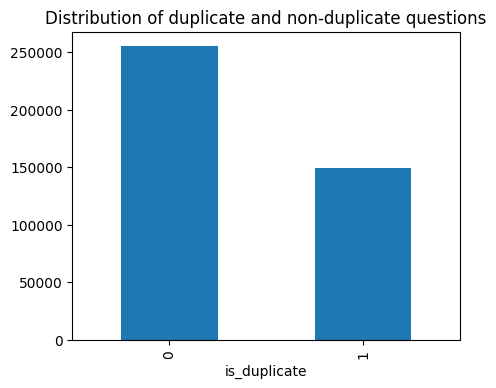

In [ ]:
# distribution of classes
print(df['is_duplicate'].value_counts())

plt.figure(figsize=(5,4))
df['is_duplicate'].value_counts().plot(kind='bar')
plt.title("Distribution of duplicate and non-duplicate questions")
plt.show()

In [ ]:
# repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print("unique questions", np.unique(qid).shape[0])
x = qid.value_counts() > 1
print("repeated questions",x[x].shape[0])

unique questions 537933
repeated questions 111780


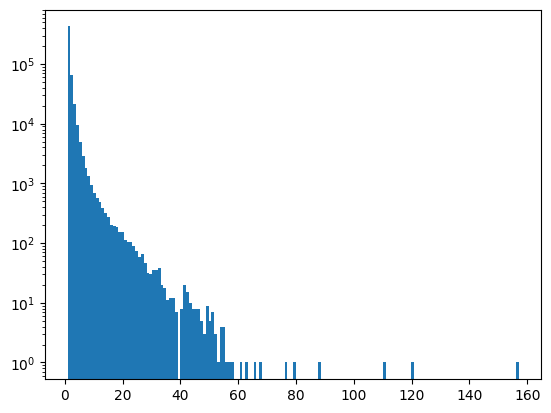

In [ ]:
# repeated questions histogram

plt.hist(qid.value_counts().values, bins=160)
plt.yscale("log")
plt.show()

# **Feature Engineering**